# Mini Assignment: Gold Price Analysis
**Student ID:** [2471369]  
**Name:** [Fu Tianyi]  
[cite_start]**Track:** Track 2 - GitHub Data Analysis Project [cite: 500]

🚀 [INIT] Initiating Quantitative Analysis Pipeline (2021-01-01 to 2026-01-01)...
✅ [DATA] Successfully ingested domestic data from 'china_gold_etf.csv'.
⚠️ [FALLBACK] Live API unavailable. Deploying local fallback pipeline...
✅ [FALLBACK] Local institutional data deployed successfully.
🧮 [COMPUTATION] Engineering quantitative metrics and indicators...
📊 [VISUALIZATION] Rendering high-fidelity dashboard...


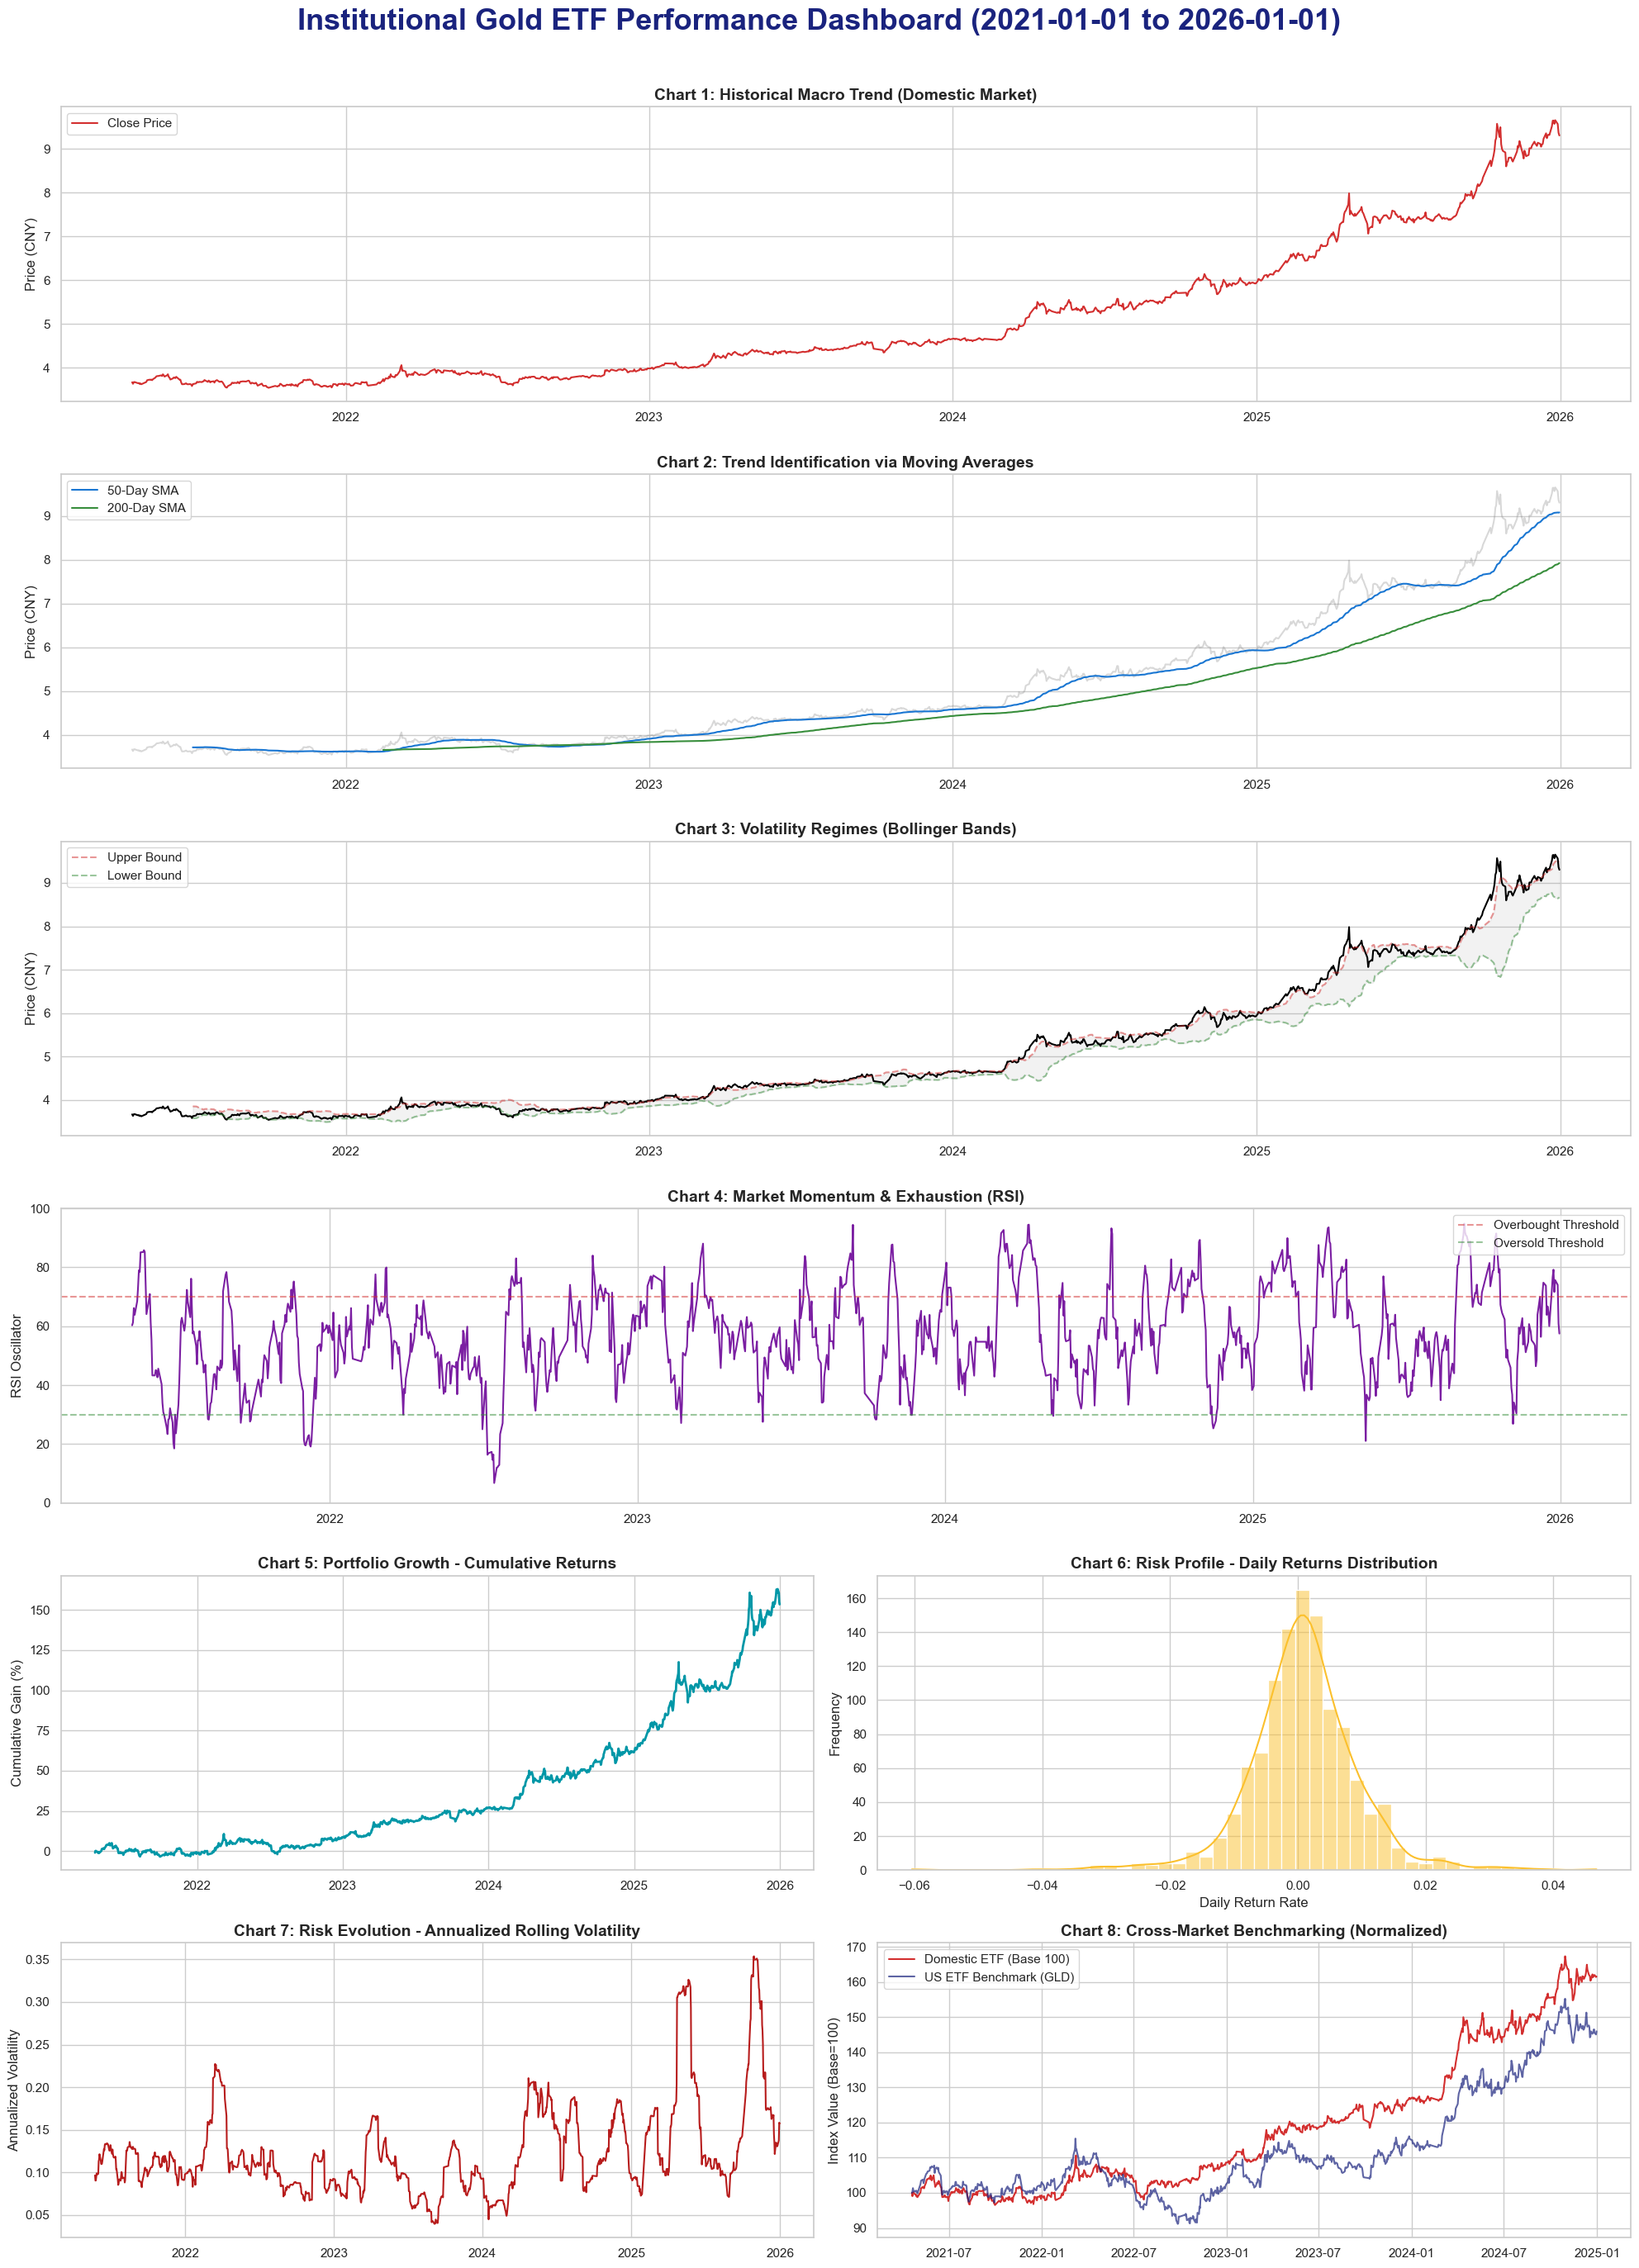

🎉 [SUCCESS] Pipeline execution complete.
📁 [EXPORT] Visualizations securely saved to local directory as 'advanced_gold_dashboard.pdf' and 'advanced_gold_dashboard.png'.


In [1]:
# ==============================================================================
# Comprehensive Cross-Market Gold Analysis Dashboard (Institutional Version)
# ==============================================================================
"""
Module: Cross-Market Gold Price Analysis
Description: A professional-grade quantitative financial tool designed to fetch, 
             process, and visualize gold ETF performance. It compares the domestic 
             Chinese market with the US market using dynamic WRDS API integration 
             and robust local fallbacks.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec
import warnings
from typing import Optional

# Suppress visual and pandas warnings for a cleaner output
warnings.filterwarnings('ignore')

# Attempt to import the Wharton Research Data Services (WRDS) module
try:
    import wrds
    WRDS_AVAILABLE = True
except ImportError:
    WRDS_AVAILABLE = False
    print("⚠️ [WARNING] 'wrds' package not found. To enable live WRDS API fetching, execute: 'pip install wrds'.")


def generate_gold_dashboard(
    china_data_source: str, 
    wrds_usr: Optional[str] = None, 
    us_ticker: str = 'GLD', 
    start_date: str = '2021-01-01', 
    end_date: str = '2026-01-01'
) -> None:
    """
    Generates a comprehensive 8-chart financial dashboard comparing gold ETFs.

    This function automates the entire quantitative workflow: data ingestion 
    (via local CSV or WRDS API), data wrangling, financial feature engineering 
    (moving averages, momentum oscillators, volatility metrics), and high-resolution 
    data visualization using matplotlib gridspec.

    Args:
        china_data_source (str): Filepath to the domestic Chinese gold ETF data.
        wrds_usr (str, optional): WRDS account username for live API access. 
                                  Defaults to None (triggers local fallback).
        us_ticker (str): The ticker symbol for the US market ETF. Defaults to 'GLD'.
        start_date (str): The start date for the analysis timeframe (YYYY-MM-DD).
        end_date (str): The end date for the analysis timeframe (YYYY-MM-DD).

    Returns:
        None. The function renders a matplotlib dashboard and exports it to PDF/PNG.
    """
    print(f"🚀 [INIT] Initiating Quantitative Analysis Pipeline ({start_date} to {end_date})...")

    # -------------------------------------------------------------------------
    # Phase 1: Local Data Ingestion (Chinese Market)
    # -------------------------------------------------------------------------
    try:
        df_china = pd.read_csv(china_data_source)
        df_china['Date'] = pd.to_datetime(df_china['Date'])
        df_china.set_index('Date', inplace=True)
        # Truncate dataset to the specified temporal bounds
        df_china = df_china.loc[start_date:end_date]
        print(f"✅ [DATA] Successfully ingested domestic data from '{china_data_source}'.")
    except Exception as e:
        print(f"❌ [ERROR] Failed to load domestic Chinese data. Exception: {e}")
        return

    # -------------------------------------------------------------------------
    # Phase 2: Institutional Data Fetching (US Market via WRDS/CRSP)
    # -------------------------------------------------------------------------
    df_us = pd.DataFrame()
    
    # Attempt live API connection if credentials are provided
    if WRDS_AVAILABLE and wrds_usr:
        print("🔗 [API] Attempting connection to WRDS database...")
        try:
            db = wrds.Connection(wrds_username=wrds_usr)
            # Formulate SQL query to extract daily stock files (DSF) from CRSP
            sql_query = f"""
                SELECT date, prc
                FROM crsp.dsf
                WHERE permno IN (SELECT permno FROM crsp.stocknames WHERE ticker='{us_ticker}')
                AND date >= '{start_date}' AND date <= '{end_date}'
            """
            df_us = db.raw_sql(sql_query)
            df_us['date'] = pd.to_datetime(df_us['date'])
            df_us.set_index('date', inplace=True)
            
            # CRSP utilizes negative prices to denote the average of bid/ask 
            # for days without trading volume. We apply absolute value for continuity.
            df_us['Close_US'] = df_us['prc'].abs() 
            print(f"✅ [API] Live WRDS data for '{us_ticker}' fetched successfully.")
        except Exception as e:
            print(f"❌ [API ERROR] WRDS query execution failed: {e}")
    
    # Robust Fallback Mechanism: Utilize local CSV if API fails or is unconfigured
    if df_us.empty:
        print("⚠️ [FALLBACK] Live API unavailable. Deploying local fallback pipeline...")
        try:
            df_us = pd.read_csv('wrds_gld_data.csv')
            df_us['date'] = pd.to_datetime(df_us['date'])
            df_us.set_index('date', inplace=True)
            df_us['Close_US'] = df_us['PRC'].abs()
            df_us = df_us.loc[start_date:end_date]
            print("✅ [FALLBACK] Local institutional data deployed successfully.")
        except Exception as e:
            print(f"❌ [CRITICAL] Fallback sequence failed. Missing 'wrds_gld_data.csv'. Exception: {e}")
            return

    # -------------------------------------------------------------------------
    # Phase 3: Financial Feature Engineering & Technical Indicators
    # -------------------------------------------------------------------------
    print("🧮 [COMPUTATION] Engineering quantitative metrics and indicators...")
    
    # 1. Trend Indicators (Simple Moving Averages)
    df_china['MA50'] = df_china['Close'].rolling(window=50).mean()
    df_china['MA200'] = df_china['Close'].rolling(window=200).mean()
    
    # 2. Volatility Metrics (Bollinger Bands based on 20-day standard deviation)
    df_china['STD'] = df_china['Close'].rolling(window=20).std()
    df_china['Upper_Band'] = df_china['MA50'] + (df_china['STD'] * 2)
    df_china['Lower_Band'] = df_china['MA50'] - (df_china['STD'] * 2)
    
    # 3. Momentum Oscillator (Relative Strength Index - 14-Day)
    delta = df_china['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df_china['RSI'] = 100 - (100 / (1 + (gain / loss)))

    # 4. Performance & Risk Profiling
    df_china['Returns'] = df_china['Close'].pct_change()
    # Cumulative Returns metric reflects total equity growth over the period
    df_china['Cum_Returns'] = (1 + df_china['Returns']).cumprod() - 1
    # Annualized Volatility (assuming 252 trading days in a calendar year)
    df_china['Volatility'] = df_china['Returns'].rolling(window=22).std() * np.sqrt(252)
    
    # 5. Cross-Market Normalization (Base=100 indexing for comparative analysis)
    df_merged = pd.merge(df_china[['Close']], df_us[['Close_US']], left_index=True, right_index=True, how='inner')
    df_merged['China_Norm'] = (df_merged['Close'] / df_merged['Close'].iloc[0]) * 100
    df_merged['US_Norm'] = (df_merged['Close_US'] / df_merged['Close_US'].iloc[0]) * 100

    # -------------------------------------------------------------------------
    # Phase 4: Data Visualization & Dashboard Assembly
    # -------------------------------------------------------------------------
    print("📊 [VISUALIZATION] Rendering high-fidelity dashboard...")
    
    plt.rcParams.update({'font.size': 10})
    sns.set_theme(style="whitegrid")
    
    # Instantiate a highly customizable figure environment
    fig = plt.figure(figsize=(20, 28))
    fig.suptitle(f'Institutional Gold ETF Performance Dashboard ({start_date} to {end_date})', 
                 fontsize=26, fontweight='bold', color='#1A237E') # Deep Navy
    
    gs = gridspec.GridSpec(6, 2, figure=fig) 
    
    # Chart 1: Core Price Action
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df_china.index, df_china['Close'], color='#D32F2F', label='Close Price')
    ax1.set_title('Chart 1: Historical Macro Trend (Domestic Market)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (CNY)')
    ax1.legend()

    # Chart 2: Trend Alignment (MA Crossovers)
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(df_china.index, df_china['Close'], color='gray', alpha=0.3)
    ax2.plot(df_china.index, df_china['MA50'], color='#1976D2', label='50-Day SMA')
    ax2.plot(df_china.index, df_china['MA200'], color='#388E3C', label='200-Day SMA')
    ax2.set_title('Chart 2: Trend Identification via Moving Averages', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Price (CNY)')
    ax2.legend()

    # Chart 3: Volatility Dispersions
    ax3 = fig.add_subplot(gs[2, :])
    ax3.plot(df_china.index, df_china['Close'], color='black')
    ax3.plot(df_china.index, df_china['Upper_Band'], color='#D32F2F', linestyle='--', alpha=0.5, label='Upper Bound')
    ax3.plot(df_china.index, df_china['Lower_Band'], color='#388E3C', linestyle='--', alpha=0.5, label='Lower Bound')
    ax3.fill_between(df_china.index, df_china['Upper_Band'], df_china['Lower_Band'], color='gray', alpha=0.1)
    ax3.set_title('Chart 3: Volatility Regimes (Bollinger Bands)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Price (CNY)')
    ax3.legend()

    # Chart 4: Market Sentiment
    ax4 = fig.add_subplot(gs[3, :])
    ax4.plot(df_china.index, df_china['RSI'], color='#7B1FA2')
    ax4.axhline(70, color='#D32F2F', linestyle='--', alpha=0.5, label='Overbought Threshold')
    ax4.axhline(30, color='#388E3C', linestyle='--', alpha=0.5, label='Oversold Threshold')
    ax4.set_title('Chart 4: Market Momentum & Exhaustion (RSI)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('RSI Oscillator')
    ax4.set_ylim(0, 100)
    ax4.legend(loc='upper right')

    # Chart 5: Equity Growth
    ax5 = fig.add_subplot(gs[4, 0])
    ax5.plot(df_china.index, df_china['Cum_Returns'] * 100, color='#0097A7', lw=2)
    ax5.set_title('Chart 5: Portfolio Growth - Cumulative Returns', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Cumulative Gain (%)')

    # Chart 6: Statistical Risk Profile
    ax6 = fig.add_subplot(gs[4, 1])
    sns.histplot(df_china['Returns'].dropna(), bins=50, kde=True, color='#FBC02D', ax=ax6)
    ax6.set_title('Chart 6: Risk Profile - Daily Returns Distribution', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Daily Return Rate')
    ax6.set_ylabel('Frequency')

    # Chart 7: Uncertainty Modeling
    ax7 = fig.add_subplot(gs[5, 0])
    ax7.plot(df_china.index, df_china['Volatility'], color='#B71C1C')
    ax7.set_title('Chart 7: Risk Evolution - Annualized Rolling Volatility', fontsize=14, fontweight='bold')
    ax7.set_ylabel('Annualized Volatility')

    # Chart 8: Global Arbitrage Benchmark
    ax8 = fig.add_subplot(gs[5, 1])
    ax8.plot(df_merged.index, df_merged['China_Norm'], color='#D32F2F', label='Domestic ETF (Base 100)')
    ax8.plot(df_merged.index, df_merged['US_Norm'], color='#1A237E', label=f'US ETF Benchmark ({us_ticker})', alpha=0.7)
    ax8.set_title('Chart 8: Cross-Market Benchmarking (Normalized)', fontsize=14, fontweight='bold')
    ax8.set_ylabel('Index Value (Base=100)')
    ax8.legend()

    # Optimize spacing to accommodate the super title
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Export execution
    export_pdf = 'advanced_gold_dashboard.pdf'
    export_png = 'advanced_gold_dashboard.png'
    plt.savefig(export_pdf, bbox_inches='tight')
    plt.savefig(export_png, dpi=300, bbox_inches='tight')
    plt.show()
    
    print("🎉 [SUCCESS] Pipeline execution complete.")
    print(f"📁 [EXPORT] Visualizations securely saved to local directory as '{export_pdf}' and '{export_png}'.")

# ==============================================================================
# User Execution Interface (Main Block)
# ==============================================================================
if __name__ == "__main__":
    
    # USER CONFIGURATION PARAMETERS
    # Modify these variables to customize the data pipeline behavior.
    
    # Target file for the domestic market data
    LOCAL_CHINA_DATA = 'china_gold_etf.csv'
    
    # WRDS Credentials. Replace None with 'your_username' string to activate live API.
    # Leaving it as None triggers the robust local fallback mechanism.
    WRDS_CREDENTIAL = None 
    
    # Execute the primary function
    generate_gold_dashboard(
        china_data_source=LOCAL_CHINA_DATA,
        wrds_usr=WRDS_CREDENTIAL,
        us_ticker='GLD',
        start_date='2021-01-01',
        end_date='2026-01-01'
    )